<a href="https://colab.research.google.com/github/tim202606/fruit-freshness-cnn-detection/blob/main/%E4%BD%9C%E5%93%81_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 水果好壞判別

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from google.colab import drive

drive.mount('/content/drive')
path_result = !find /content/drive/MyDrive/ -name "kaggle.json"
os.environ['KAGGLE_CONFIG_DIR'] = os.path.dirname(path_result[0])
print(f"憑證路徑設定成功：{os.environ['KAGGLE_CONFIG_DIR']}")

import kagglehub
data_dir = kagglehub.dataset_download("sriramr/fruits-fresh-and-rotten-for-classification")
print(f"下載資料路徑在：{data_dir}")


Mounted at /content/drive
憑證路徑設定成功：/content/drive/MyDrive/三民kaggle
Using Colab cache for faster access to the 'fruits-fresh-and-rotten-for-classification' dataset.
下載資料路徑在：/kaggle/input/fruits-fresh-and-rotten-for-classification


In [ ]:
import tensorflow as tf

train_dir = os.path.join(data_dir, 'dataset', 'dataset', 'train')
test_dir = os.path.join(data_dir, 'dataset', 'dataset', 'test')

IMG_SIZE = (150,150)
BATCH_SIZE = 32

print("正在載入訓練集資料(Train)...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print("正在載入測試集資料(Test)...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"類別總數：{num_classes}，分別為：{class_names}")


正在載入訓練集資料(Train)...
Found 10901 files belonging to 6 classes.
正在載入測試集資料(Test)...
Found 2698 files belonging to 6 classes.
類別總數：6，分別為：['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomZoom, Input, Rescaling
from tensorflow.keras.callbacks import EarlyStopping

# 影像增強
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.2),
])

# 模型結構
model = Sequential([
    Input(shape=(150,150,3)),
    data_augmentation,
    Rescaling(1./255),

    Conv2D(32,(3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# 編譯模型
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("模型開始訓練...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)
print("訓練完成")

# 儲存模型
model.save('/content/drive/MyDrive/fruit_model.h5')
print("模型已儲存到雲端硬碟！")



模型開始訓練...
Epoch 1/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 72s 190ms/step - accuracy: 0.5743 - loss: 1.1325 - val_accuracy: 0.8039 - val_loss: 0.6113
Epoch 2/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 43s 127ms/step - accuracy: 0.7852 - loss: 0.6615 - val_accuracy: 0.8721 - val_loss: 0.4067
Epoch 3/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 43s 127ms/step - accuracy: 0.8236 - loss: 0.5422 - val_accuracy: 0.8725 - val_loss: 0.3610
Epoch 4/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 45s 132ms/step - accuracy: 0.8426 - loss: 0.4791 - val_accuracy: 0.8951 - val_loss: 0.3152
Epoch 5/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 80s 126ms/step - accuracy: 0.8579 - loss: 0.4260 - val_accuracy: 0.9018 - val_loss: 0.2680
Epoch 6/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 82s 127ms/step - accuracy: 0.8676 - loss: 0.4044 - val_accuracy: 0.9136 - val_loss: 0.2583
Epoch 7/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - accuracy: 0.8692 - loss: 0.3791 - val_accuracy: 0.9007 - val_loss: 0.2637
Epoch 8/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 83s 136ms/step - accuracy: 0.8773

訓練完成
模型已儲存到雲端硬碟！


中文字體系統安裝成功！


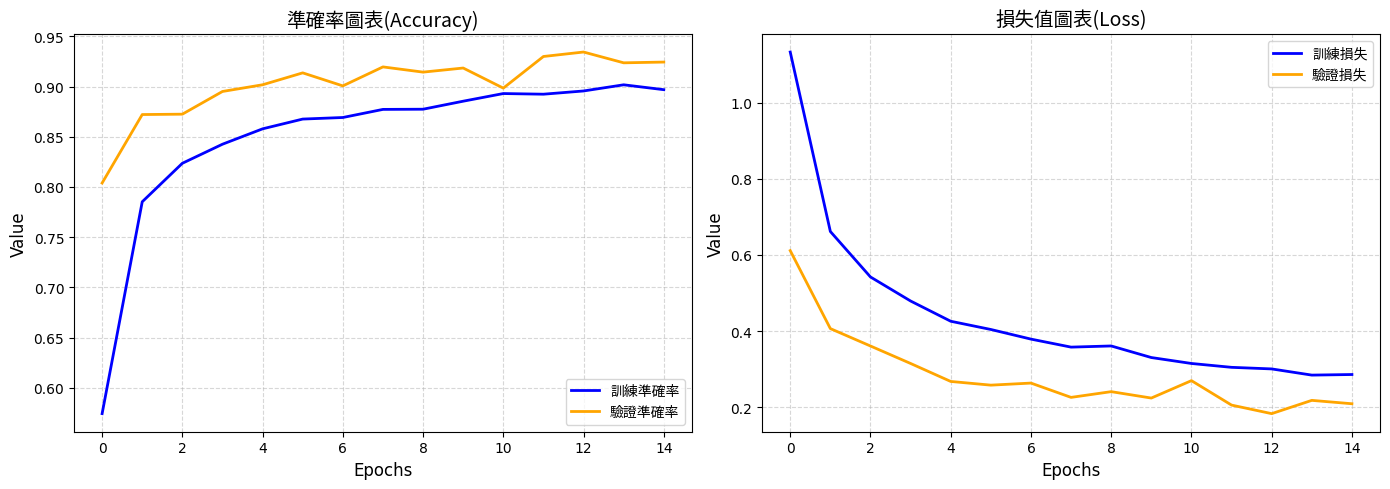

In [ ]:


# 用Linux系統內建指令安裝官方中文字體
!apt-get install -y fonts-noto-cjk > /dev/null
print("中文字體系統安裝成功！")

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 指定系統內建的Noto繁體中文字體路徑
font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
font_prop = fm.FontProperties(fname=font_path)

# 取數據
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14,5))

# 左圖：準確率
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='訓練準確率', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='驗證準確率', color='orange', linewidth=2)
plt.title('準確率圖表(Accuracy)', fontproperties=font_prop, fontsize=14, fontweight='bold')
plt.legend(prop=font_prop, loc='lower right', fontsize=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 右圖：損失值
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='訓練損失', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='驗證損失', color='orange', linewidth=2)
plt.title('損失值圖表(Loss)', fontproperties=font_prop, fontsize=14, fontweight='bold')
plt.legend(prop=font_prop, loc='upper right', fontsize=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# 實測模型

In [ ]:
!unzip -q tryfruits.zip -d /content/test_images


In [ ]:
import glob
import os
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model('/content/drive/MyDrive/fruit_model.h5')
print("模型載入成功!")
target_dir = '/content/test_images'
os.makedirs(target_dir, exist_ok=True)
all_files = glob.glob(f'{target_dir}/**/*', recursive=True)
print("開始進行圖片預測...")
has_images = False

for img_path in all_files:
    if os.path.isdir(img_path):
        continue
    if not img_path.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        continue
    has_images = True

    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array,0)
    predictions = model.predict(img_array,verbose=0)

    file_name = os.path.basename(img_path)
    predicted_class = class_names[np.argmax(predictions)]
    print(f"圖片: {file_name} -> 預測結果: {predicted_class}")

if not has_images:
    print(f"目前'{target_dir}'資料夾內沒有任何圖片")


模型載入成功!
開始進行圖片預測...
圖片: rotten-b2.jpg -> 預測結果: rottenoranges
圖片: fresh-a1.jpg -> 預測結果: rottenapples
圖片: rotten-a1.jpg -> 預測結果: rottenapples
圖片: rotten-a2.jpg -> 預測結果: rottenapples
圖片: fresh-b1.jpg -> 預測結果: freshbanana
圖片: rotten-o1.jpg -> 預測結果: rottenoranges
圖片: rotten-b1.jpg -> 預測結果: rottenbanana
圖片: fresh-a2.jpg -> 預測結果: freshapples
圖片: fresh-b2.jpg -> 預測結果: freshoranges
圖片: fresh-o1.jpg -> 預測結果: freshoranges
圖片: rotten-o2.jpg -> 預測結果: rottenoranges
圖片: fresh-o2.jpg -> 預測結果: rottenoranges
